**Jupyter Notebook for Experimenting w/ MSE-optimized TQ**

In [55]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import sys
from sklearn.metrics import mean_squared_error

[[0.14334251]
 [0.15552945]
 [0.13844514]
 [0.04983199]
 [0.04865432]
 [0.12127454]
 [0.15289508]
 [0.10014234]
 [0.08180489]
 [0.07772774]
 [0.1353012 ]
 [0.0892347 ]
 [0.15797259]
 [0.07870412]
 [0.14873642]
 [0.08842223]
 [0.15899014]
 [0.14178041]
 [0.14220255]
 [0.00221495]
 [0.13174781]
 [0.07007066]
 [0.0329823 ]
 [0.00319727]
 [0.04162115]
 [0.15587703]
 [0.13714703]
 [0.15757165]
 [0.14077543]
 [0.00384106]
 [0.07086239]
 [0.13078147]
 [0.07671827]
 [0.12033896]
 [0.08166154]
 [0.15615461]
 [0.01073341]
 [0.137204  ]
 [0.13558792]
 [0.05515933]
 [0.07068363]
 [0.10269831]
 [0.10537516]
 [0.04065008]
 [0.12165141]
 [0.00856298]
 [0.04431498]
 [0.13600469]
 [0.15491214]
 [0.02517863]
 [0.08506869]
 [0.02940282]
 [0.15207179]
 [0.13627425]
 [0.11666105]
 [0.08966529]
 [0.00420856]
 [0.00098365]
 [0.01988799]
 [0.01192073]
 [0.01957812]
 [0.05996169]
 [0.00261171]
 [0.02652397]
 [0.02641132]
 [0.01823401]
 [0.12000772]
 [0.12663853]
 [0.10864444]
 [0.05812125]
 [0.07526605]
 [0.13

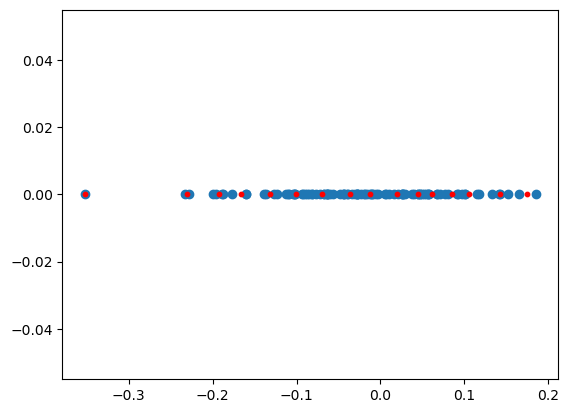

928
512
5.2759435925418166e-05


/var/folders/0r/1vl6m01x51bd7ldb8wkg1k2w0000gn/T/ipykernel_1265/2499045419.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  recon[i] = centroids[labels[i]]


In [56]:
d = 100
b = 4
M = np.random.rand(d,d)
x = np.random.rand(d, 1)
xHat = x / np.linalg.norm(x)

## what's going on with the dimension of x and M and shit

Q = np.linalg.qr(M)[0]

y = Q @ xHat
print(xHat)

km = KMeans(n_clusters=(2**b), algorithm='lloyd').fit(y)
centroids = km.cluster_centers_
labels = km.labels_
plt.scatter(y, np.zeros(d))
plt.scatter(km.cluster_centers_, np.zeros(2**b), c='red', s=10)
plt.show()

print(sys.getsizeof(xHat))
print(sys.getsizeof(labels))

## rebuild the vector
recon = np.zeros(d)
for i in range(d):
    recon[i] = centroids[labels[i]]

recon = Q.T @ recon
# print(recon)

## get MSE
print(mean_squared_error(xHat, recon))
